In [9]:
import pandas as pd
df=pd.read_csv("/content/cleaned_churn_data.csv")
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [10]:
df.shape

(7043, 31)

In [11]:
x=df.drop('Churn_Yes',axis=1)
y=df['Churn_Yes']

In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=5000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=5000)

In [17]:
x_train.dtypes

,0
SeniorCitizen,int64
tenure,int64
MonthlyCharges,float64
TotalCharges,float64
gender_Male,bool
Partner_Yes,bool
Dependents_Yes,bool
PhoneService_Yes,bool
MultipleLines_No phone service,bool
MultipleLines_Yes,bool


In [18]:
y_pred=model.predict(x_test)

In [19]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.8211497515968772


In [20]:
from sklearn.metrics import precision_score
precision=precision_score(y_test,y_pred)
print(precision)

0.6861538461538461


In [21]:
from sklearn.metrics import recall_score
recall=recall_score(y_test,y_pred)
print(recall)

0.5978552278820375


In [22]:
from sklearn.metrics import f1_score
f1=f1_score(y_test,y_pred)
print(f1)

0.6389684813753582


In [25]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)
y_pred_tree=model.predict(x_test)

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("\nDecision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1:", f1_score(y_test, y_pred_tree))

Logistic Regression
Accuracy: 0.8211497515968772
Precision: 0.6861538461538461
Recall: 0.5978552278820375
F1: 0.6389684813753582

Decision Tree
Accuracy: 0.709013484740951
Precision: 0.45144356955380577
Recall: 0.46112600536193027
F1: 0.4562334217506631


In [30]:
importance = model.feature_importances_
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

                                  Feature  Importance
2                          MonthlyCharges    0.203161
1                                  tenure    0.202276
3                            TotalCharges    0.199242
10            InternetService_Fiber optic    0.103833
0                           SeniorCitizen    0.023166
26                   PaperlessBilling_Yes    0.021871
6                          Dependents_Yes    0.021292
28         PaymentMethod_Electronic check    0.020725
4                             gender_Male    0.020545
5                             Partner_Yes    0.020406
13                     OnlineSecurity_Yes    0.019477
15                       OnlineBackup_Yes    0.018568
17                   DeviceProtection_Yes    0.018335
27  PaymentMethod_Credit card (automatic)    0.017580
24                      Contract_One year    0.014358
9                       MultipleLines_Yes    0.013487
19                        TechSupport_Yes    0.012069
29             PaymentMethod

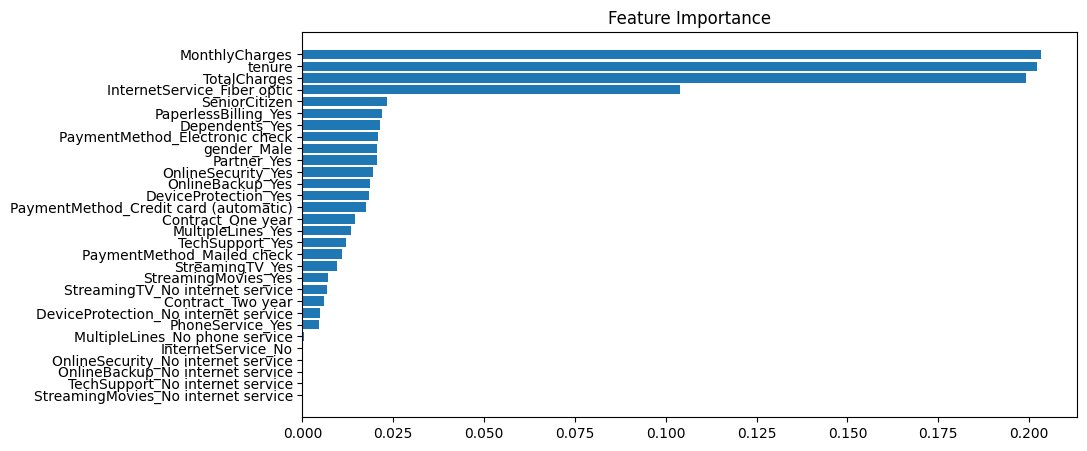

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [32]:
feature_importance = feature_importance.sort_values(by="Importance", ascending=True)
top_features = feature_importance.tail(10)
top_features

,Feature,Importance
5,Partner_Yes,0.020406
4,gender_Male,0.020545
28,PaymentMethod_Electronic check,0.020725
6,Dependents_Yes,0.021292
26,PaperlessBilling_Yes,0.021871
0,SeniorCitizen,0.023166
10,InternetService_Fiber optic,0.103833
3,TotalCharges,0.199242
1,tenure,0.202276
2,MonthlyCharges,0.203161


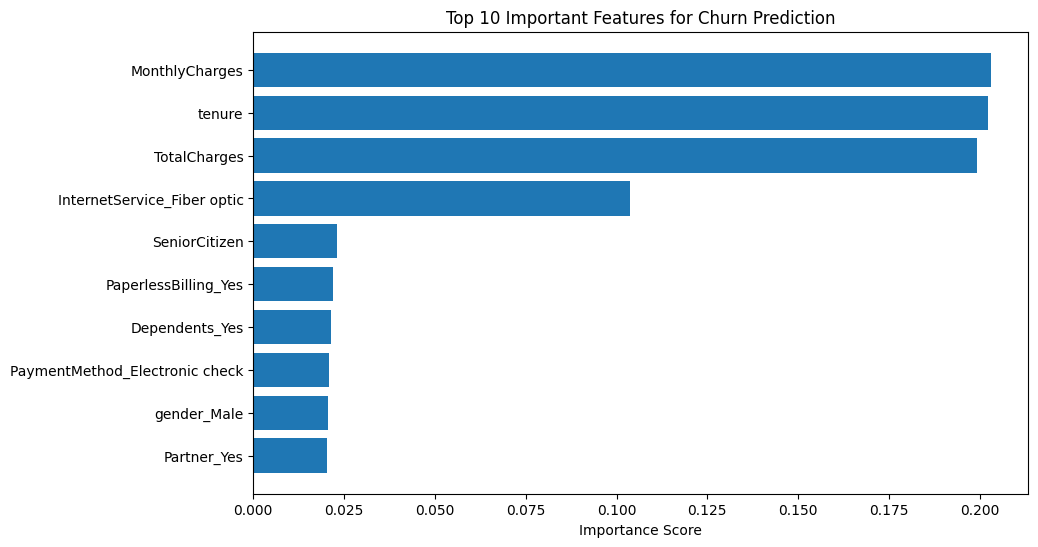

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance Score")
plt.title("Top 10 Important Features for Churn Prediction")
plt.show()

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
param_grid = {
    "max_depth": [3, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]}

In [40]:
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1)
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 10, 15],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1')

In [43]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [45]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(x_test)

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Tuned Decision Tree Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))

Tuned Decision Tree Performance
Accuracy: 0.8076650106458482
Precision: 0.7107438016528925
Recall: 0.46112600536193027
F1 Score: 0.5593495934959349
